In [ ]:
!pip install scikit-fuzzy kneed

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 4.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import pandas as pd
import datetime as dt
import numpy as np
import os
import joblib
import json
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed
from itertools import product
import matplotlib.pyplot as plt

import skfuzzy as fuzz
from kneed import KneeLocator

In [ ]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
dataset = "/content/drive/MyDrive/Research - Model Data Driven untuk Segmentasi Loyalitas Pelanggan dan Strategi Penjualan pada E-Commerce Menggunakan Metode Fuzzy C-Means dan Big Data Analytics/JD.com/JD_order_data.csv"

In [ ]:
df = pd.read_csv(dataset)
df

,order_ID,user_ID,sku_ID,order_date,order_time,quantity,type,promise,original_unit_price,final_unit_price,direct_discount_per_unit,quantity_discount_per_unit,bundle_discount_per_unit,coupon_discount_per_unit,gift_item,dc_ori,dc_des
0,d0cf5cc6db,0abe9ef2ce,581d5b54c1,2018-03-01,2018-03-01 17:14:25.0,1,2,-,89.0,79.0,0.0,10.0,0.0,0.0,0,4,28
1,7444318d01,33a9e56257,067b673f2b,2018-03-01,2018-03-01 11:10:40.0,1,1,2,99.9,53.9,5.0,41.0,0.0,0.0,0,28,28
2,f973b01694,4ea3cf408f,623d0a582a,2018-03-01,2018-03-01 09:13:26.0,1,1,2,78.0,58.5,19.5,0.0,0.0,0.0,0,28,28
3,8c1cec8d4b,b87cb736cb,fc5289b139,2018-03-01,2018-03-01 21:29:50.0,1,1,2,61.0,35.0,0.0,26.0,0.0,0.0,0,4,28
4,d43a33c38a,4829223b6f,623d0a582a,2018-03-01,2018-03-01 19:13:37.0,1,1,1,78.0,53.0,19.0,0.0,0.0,6.0,0,3,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549984,3ad06b9fbe,a27b3ed4d4,a9109972d1,2018-03-31,2018-03-31 01:22:47.0,1,2,-,0.0,-1.0,0.0,0.0,0.0,1.0,1,2,2
549985,c9d77a7ed0,18f92434cd,7f53769d3f,2018-03-31,2018-03-31 08:55:57.0,1,1,3,118.0,55.0,63.0,0.0,0.0,0.0,0,59,2
549986,b9ad79338f,b5caf8a580,8dc4a01dec,2018-03-31,2018-03-31 13:31:01.0,1,1,2,78.0,78.0,0.0,0.0,0.0,0.0,0,2,2
549987,be3a9414b1,20ba6655f3,2dd6b818ec,2018-03-31,2018-03-31 12:51:18.0,1,2,-,189.0,78.0,111.0,0.0,0.0,0.0,0,4,28


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549989 entries, 0 to 549988
Data columns (total 17 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   order_ID                    549989 non-null  object 
 1   user_ID                     549989 non-null  object 
 2   sku_ID                      549989 non-null  object 
 3   order_date                  549989 non-null  object 
 4   order_time                  549989 non-null  object 
 5   quantity                    549989 non-null  int64  
 6   type                        549989 non-null  int64  
 7   promise                     549989 non-null  object 
 8   original_unit_price         549989 non-null  float64
 9   final_unit_price            549989 non-null  float64
 10  direct_discount_per_unit    549989 non-null  float64
 11  quantity_discount_per_unit  549989 non-null  float64
 12  bundle_discount_per_unit    549989 non-null  float64
 13  coupon_discoun

In [ ]:
df.describe()

,quantity,type,original_unit_price,final_unit_price,direct_discount_per_unit,quantity_discount_per_unit,bundle_discount_per_unit,coupon_discount_per_unit,gift_item,dc_ori,dc_des
count,549989.000000,549989.000000,549989.000000,549989.000000,549989.000000,549989.000000,549989.000000,549989.000000,549989.000000,549989.000000,549989.000000
mean,1.216670,1.499139,102.813542,71.572599,19.845889,7.843390,0.625649,2.926015,0.172014,12.062714,21.679845
std,1.844589,0.500000,95.035563,75.879057,33.593536,17.994354,6.442281,11.588338,0.377393,14.201200,16.973899
min,1.000000,1.000000,0.000000,-32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,1.000000,1.000000,59.000000,33.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,5.000000
50%,1.000000,1.000000,79.000000,58.000000,4.000000,0.000000,0.000000,0.000000,0.000000,7.000000,20.000000
75%,1.000000,2.000000,139.000000,95.000000,21.000000,0.000000,0.000000,0.000000,0.000000,10.000000,34.000000
max,400.000000,2.000000,12158.000000,12158.000000,720.000000,225.000000,252.000000,210.000000,1.000000,67.000000,67.000000


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df

,order_ID,user_ID,sku_ID,order_date,order_time,quantity,type,promise,original_unit_price,final_unit_price,direct_discount_per_unit,quantity_discount_per_unit,bundle_discount_per_unit,coupon_discount_per_unit,gift_item,dc_ori,dc_des
0,d0cf5cc6db,0abe9ef2ce,581d5b54c1,2018-03-01,2018-03-01 17:14:25.0,1,2,-,89.0,79.0,0.0,10.0,0.0,0.0,0,4,28
1,7444318d01,33a9e56257,067b673f2b,2018-03-01,2018-03-01 11:10:40.0,1,1,2,99.9,53.9,5.0,41.0,0.0,0.0,0,28,28
2,f973b01694,4ea3cf408f,623d0a582a,2018-03-01,2018-03-01 09:13:26.0,1,1,2,78.0,58.5,19.5,0.0,0.0,0.0,0,28,28
3,8c1cec8d4b,b87cb736cb,fc5289b139,2018-03-01,2018-03-01 21:29:50.0,1,1,2,61.0,35.0,0.0,26.0,0.0,0.0,0,4,28
4,d43a33c38a,4829223b6f,623d0a582a,2018-03-01,2018-03-01 19:13:37.0,1,1,1,78.0,53.0,19.0,0.0,0.0,6.0,0,3,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549984,3ad06b9fbe,a27b3ed4d4,a9109972d1,2018-03-31,2018-03-31 01:22:47.0,1,2,-,0.0,-1.0,0.0,0.0,0.0,1.0,1,2,2
549985,c9d77a7ed0,18f92434cd,7f53769d3f,2018-03-31,2018-03-31 08:55:57.0,1,1,3,118.0,55.0,63.0,0.0,0.0,0.0,0,59,2
549986,b9ad79338f,b5caf8a580,8dc4a01dec,2018-03-31,2018-03-31 13:31:01.0,1,1,2,78.0,78.0,0.0,0.0,0.0,0.0,0,2,2
549987,be3a9414b1,20ba6655f3,2dd6b818ec,2018-03-31,2018-03-31 12:51:18.0,1,2,-,189.0,78.0,111.0,0.0,0.0,0.0,0,4,28


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df

,order_ID,user_ID,sku_ID,order_date,order_time,quantity,type,promise,original_unit_price,final_unit_price,direct_discount_per_unit,quantity_discount_per_unit,bundle_discount_per_unit,coupon_discount_per_unit,gift_item,dc_ori,dc_des
0,d0cf5cc6db,0abe9ef2ce,581d5b54c1,2018-03-01,2018-03-01 17:14:25.0,1,2,-,89.0,79.0,0.0,10.0,0.0,0.0,0,4,28
1,7444318d01,33a9e56257,067b673f2b,2018-03-01,2018-03-01 11:10:40.0,1,1,2,99.9,53.9,5.0,41.0,0.0,0.0,0,28,28
2,f973b01694,4ea3cf408f,623d0a582a,2018-03-01,2018-03-01 09:13:26.0,1,1,2,78.0,58.5,19.5,0.0,0.0,0.0,0,28,28
3,8c1cec8d4b,b87cb736cb,fc5289b139,2018-03-01,2018-03-01 21:29:50.0,1,1,2,61.0,35.0,0.0,26.0,0.0,0.0,0,4,28
4,d43a33c38a,4829223b6f,623d0a582a,2018-03-01,2018-03-01 19:13:37.0,1,1,1,78.0,53.0,19.0,0.0,0.0,6.0,0,3,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549984,3ad06b9fbe,a27b3ed4d4,a9109972d1,2018-03-31,2018-03-31 01:22:47.0,1,2,-,0.0,-1.0,0.0,0.0,0.0,1.0,1,2,2
549985,c9d77a7ed0,18f92434cd,7f53769d3f,2018-03-31,2018-03-31 08:55:57.0,1,1,3,118.0,55.0,63.0,0.0,0.0,0.0,0,59,2
549986,b9ad79338f,b5caf8a580,8dc4a01dec,2018-03-31,2018-03-31 13:31:01.0,1,1,2,78.0,78.0,0.0,0.0,0.0,0.0,0,2,2
549987,be3a9414b1,20ba6655f3,2dd6b818ec,2018-03-31,2018-03-31 12:51:18.0,1,2,-,189.0,78.0,111.0,0.0,0.0,0.0,0,4,28


In [ ]:
calculated_price = (
    df['original_unit_price'] -
    df['direct_discount_per_unit'] -
    df['quantity_discount_per_unit'] -
    df['bundle_discount_per_unit'] -
    df['coupon_discount_per_unit']
)

# 2. Kita cek selisihnya dengan final_unit_price di dataset
# Kita pakai pembulatan (abs < 0.01) untuk menghindari error desimal kecil di Python
selisih = abs(df['final_unit_price'] - calculated_price)
mismatch_data = df[selisih > 0.01]

# 3. Tampilkan hasilnya
print(f"Total baris data: {len(df)}")
print(f"Jumlah baris yang harganya JANGGAL (tidak sesuai rumus): {len(mismatch_data)}")

# Kalau ada yang janggal, kita lihat contoh datanya
if len(mismatch_data) > 0:
    print("\nContoh data yang bocor/janggal:")
    print(mismatch_data[['original_unit_price', 'final_unit_price', 'direct_discount_per_unit', 'quantity_discount_per_unit', 'bundle_discount_per_unit', 'coupon_discount_per_unit']].head())

Total baris data: 549989
Jumlah baris yang harganya JANGGAL (tidak sesuai rumus): 0


In [ ]:
df = df[(df["quantity"] > 0) & (df["final_unit_price"] > 0)].copy()
df

,order_ID,user_ID,sku_ID,order_date,order_time,quantity,type,promise,original_unit_price,final_unit_price,direct_discount_per_unit,quantity_discount_per_unit,bundle_discount_per_unit,coupon_discount_per_unit,gift_item,dc_ori,dc_des
0,d0cf5cc6db,0abe9ef2ce,581d5b54c1,2018-03-01,2018-03-01 17:14:25.0,1,2,-,89.0,79.0,0.0,10.0,0.0,0.0,0,4,28
1,7444318d01,33a9e56257,067b673f2b,2018-03-01,2018-03-01 11:10:40.0,1,1,2,99.9,53.9,5.0,41.0,0.0,0.0,0,28,28
2,f973b01694,4ea3cf408f,623d0a582a,2018-03-01,2018-03-01 09:13:26.0,1,1,2,78.0,58.5,19.5,0.0,0.0,0.0,0,28,28
3,8c1cec8d4b,b87cb736cb,fc5289b139,2018-03-01,2018-03-01 21:29:50.0,1,1,2,61.0,35.0,0.0,26.0,0.0,0.0,0,4,28
4,d43a33c38a,4829223b6f,623d0a582a,2018-03-01,2018-03-01 19:13:37.0,1,1,1,78.0,53.0,19.0,0.0,0.0,6.0,0,3,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549982,f1a1f20e07,6208a6bceb,6cb24edcc6,2018-03-31,2018-03-31 22:06:43.0,1,2,-,59.0,39.0,0.0,0.0,0.0,20.0,0,2,2
549985,c9d77a7ed0,18f92434cd,7f53769d3f,2018-03-31,2018-03-31 08:55:57.0,1,1,3,118.0,55.0,63.0,0.0,0.0,0.0,0,59,2
549986,b9ad79338f,b5caf8a580,8dc4a01dec,2018-03-31,2018-03-31 13:31:01.0,1,1,2,78.0,78.0,0.0,0.0,0.0,0.0,0,2,2
549987,be3a9414b1,20ba6655f3,2dd6b818ec,2018-03-31,2018-03-31 12:51:18.0,1,2,-,189.0,78.0,111.0,0.0,0.0,0.0,0,4,28


In [ ]:
df["total_price"] = df["quantity"] * df["final_unit_price"]
df

,order_ID,user_ID,sku_ID,order_date,order_time,quantity,type,promise,original_unit_price,final_unit_price,direct_discount_per_unit,quantity_discount_per_unit,bundle_discount_per_unit,coupon_discount_per_unit,gift_item,dc_ori,dc_des,total_price
0,d0cf5cc6db,0abe9ef2ce,581d5b54c1,2018-03-01,2018-03-01 17:14:25.0,1,2,-,89.0,79.0,0.0,10.0,0.0,0.0,0,4,28,79.0
1,7444318d01,33a9e56257,067b673f2b,2018-03-01,2018-03-01 11:10:40.0,1,1,2,99.9,53.9,5.0,41.0,0.0,0.0,0,28,28,53.9
2,f973b01694,4ea3cf408f,623d0a582a,2018-03-01,2018-03-01 09:13:26.0,1,1,2,78.0,58.5,19.5,0.0,0.0,0.0,0,28,28,58.5
3,8c1cec8d4b,b87cb736cb,fc5289b139,2018-03-01,2018-03-01 21:29:50.0,1,1,2,61.0,35.0,0.0,26.0,0.0,0.0,0,4,28,35.0
4,d43a33c38a,4829223b6f,623d0a582a,2018-03-01,2018-03-01 19:13:37.0,1,1,1,78.0,53.0,19.0,0.0,0.0,6.0,0,3,16,53.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549982,f1a1f20e07,6208a6bceb,6cb24edcc6,2018-03-31,2018-03-31 22:06:43.0,1,2,-,59.0,39.0,0.0,0.0,0.0,20.0,0,2,2,39.0
549985,c9d77a7ed0,18f92434cd,7f53769d3f,2018-03-31,2018-03-31 08:55:57.0,1,1,3,118.0,55.0,63.0,0.0,0.0,0.0,0,59,2,55.0
549986,b9ad79338f,b5caf8a580,8dc4a01dec,2018-03-31,2018-03-31 13:31:01.0,1,1,2,78.0,78.0,0.0,0.0,0.0,0.0,0,2,2,78.0
549987,be3a9414b1,20ba6655f3,2dd6b818ec,2018-03-31,2018-03-31 12:51:18.0,1,2,-,189.0,78.0,111.0,0.0,0.0,0.0,0,4,28,78.0


In [ ]:
snapshot_date = df["order_date"].max() + dt.timedelta(days=1)
snapshot_date

Timestamp('2018-04-01 00:00:00')

In [ ]:
lrfm_df = df.groupby('user_ID').agg({
    'order_date': ['min', 'max'], # Untuk hitung Length dan Recency
    'order_ID': 'nunique', # Untuk hitung Frequency (pesanan unik)
    'total_price': 'sum' # Untuk hitung Monetary
}).reset_index()

In [ ]:
lrfm_df.columns = ["user_ID", "first_order", "last_order", "frequency", "monetary"]

In [ ]:
lrfm_df["length"] = (lrfm_df["last_order"] - lrfm_df["first_order"]).dt.days
lrfm_df

,user_ID,first_order,last_order,frequency,monetary,length
0,000089d6a6,2018-03-14,2018-03-14,1,215.0,0
1,0000babd1f,2018-03-22,2018-03-22,1,39.0,0
2,0000bc018b,2018-03-30,2018-03-30,1,79.0,0
3,0000d0e5ab,2018-03-28,2018-03-28,1,228.0,0
4,0000dce472,2018-03-18,2018-03-18,1,111.5,0
...,...,...,...,...,...,...
403883,ffff03373a,2018-03-06,2018-03-06,1,44.9,0
403884,ffff0b5ecd,2018-03-28,2018-03-28,1,129.0,0
403885,ffff38690b,2018-03-16,2018-03-16,1,237.0,0
403886,ffffb20ef7,2018-03-24,2018-03-24,1,59.0,0


In [ ]:
lrfm_df["recency"] = (snapshot_date - lrfm_df["last_order"]).dt.days
lrfm_df

,user_ID,first_order,last_order,frequency,monetary,length,recency
0,000089d6a6,2018-03-14,2018-03-14,1,215.0,0,18
1,0000babd1f,2018-03-22,2018-03-22,1,39.0,0,10
2,0000bc018b,2018-03-30,2018-03-30,1,79.0,0,2
3,0000d0e5ab,2018-03-28,2018-03-28,1,228.0,0,4
4,0000dce472,2018-03-18,2018-03-18,1,111.5,0,14
...,...,...,...,...,...,...,...
403883,ffff03373a,2018-03-06,2018-03-06,1,44.9,0,26
403884,ffff0b5ecd,2018-03-28,2018-03-28,1,129.0,0,4
403885,ffff38690b,2018-03-16,2018-03-16,1,237.0,0,16
403886,ffffb20ef7,2018-03-24,2018-03-24,1,59.0,0,8


In [ ]:
lrfm_df = lrfm_df[["user_ID", "length", "recency", "frequency", "monetary"]]
lrfm_df

,user_ID,length,recency,frequency,monetary
0,000089d6a6,0,18,1,215.0
1,0000babd1f,0,10,1,39.0
2,0000bc018b,0,2,1,79.0
3,0000d0e5ab,0,4,1,228.0
4,0000dce472,0,14,1,111.5
...,...,...,...,...,...
403883,ffff03373a,0,26,1,44.9
403884,ffff0b5ecd,0,4,1,129.0
403885,ffff38690b,0,16,1,237.0
403886,ffffb20ef7,0,8,1,59.0


In [ ]:
lrfm_df.describe()

,length,recency,frequency,monetary
count,403888.000000,403888.000000,403888.000000,4.038880e+05
mean,0.237754,15.923278,1.069443,1.128204e+02
std,1.897919,9.723266,1.368416,4.782506e+02
min,0.000000,1.000000,1.000000,7.105427e-15
25%,0.000000,7.000000,1.000000,5.400000e+01
50%,0.000000,16.000000,1.000000,7.700000e+01
75%,0.000000,25.000000,1.000000,1.350000e+02
max,30.000000,31.000000,520.000000,2.120882e+05


In [ ]:
lrfm_log = lrfm_df.copy()
lrfm_log.head()

,user_ID,length,recency,frequency,monetary
0,000089d6a6,0,18,1,215.0
1,0000babd1f,0,10,1,39.0
2,0000bc018b,0,2,1,79.0
3,0000d0e5ab,0,4,1,228.0
4,0000dce472,0,14,1,111.5


In [ ]:
features = ["length", "recency", "frequency", "monetary"]

In [ ]:
for col in features:
    lrfm_log[col] = np.log1p(lrfm_log[col])

In [ ]:
lrfm_log

,user_ID,length,recency,frequency,monetary
0,000089d6a6,0.0,2.944439,0.693147,5.375278
1,0000babd1f,0.0,2.397895,0.693147,3.688879
2,0000bc018b,0.0,1.098612,0.693147,4.382027
3,0000d0e5ab,0.0,1.609438,0.693147,5.433722
4,0000dce472,0.0,2.708050,0.693147,4.722953
...,...,...,...,...,...
403883,ffff03373a,0.0,3.295837,0.693147,3.826465
403884,ffff0b5ecd,0.0,1.609438,0.693147,4.867534
403885,ffff38690b,0.0,2.833213,0.693147,5.472271
403886,ffffb20ef7,0.0,2.197225,0.693147,4.094345


In [ ]:
scaler = StandardScaler()
lrfm_scaled = scaler.fit_transform(lrfm_log[features])

In [ ]:
lrfm_scaled_df = pd.DataFrame(lrfm_scaled, columns=features)
lrfm_scaled_df.head()

,length,recency,frequency,monetary
0,-0.15388,0.457907,-0.210791,1.297526
1,-0.15388,-0.236174,-0.210791,-1.017864
2,-0.15388,-1.886194,-0.210791,-0.066187
3,-0.15388,-1.237473,-0.210791,1.377768
4,-0.15388,0.157706,-0.210791,0.401898


In [ ]:
lrfm_scaled_df.insert(0, "user_ID", lrfm_df["user_ID"])
lrfm_scaled_df.head()

,user_ID,length,recency,frequency,monetary
0,000089d6a6,-0.15388,0.457907,-0.210791,1.297526
1,0000babd1f,-0.15388,-0.236174,-0.210791,-1.017864
2,0000bc018b,-0.15388,-1.886194,-0.210791,-0.066187
3,0000d0e5ab,-0.15388,-1.237473,-0.210791,1.377768
4,0000dce472,-0.15388,0.157706,-0.210791,0.401898


In [ ]:
lrfm_scaled_df.describe()

,length,recency,frequency,monetary
count,4.038880e+05,4.038880e+05,4.038880e+05,4.038880e+05
mean,8.324803e-17,4.007763e-16,-1.147810e-15,9.363821e-16
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-1.538799e-01,-2.401113e+00,-2.107909e-01,-6.082617e+00
25%,-1.538799e-01,-6.405935e-01,-2.107909e-01,-5.806334e-01
50%,-1.538799e-01,3.166561e-01,-2.107909e-01,-1.009481e-01
75%,-1.538799e-01,8.562349e-01,-2.107909e-01,6.623540e-01
max,9.785087e+00,1.119926e+00,5.001854e+01,1.075664e+01


# **Fuzzy C Means Clustering**

In [ ]:
X = lrfm_scaled_df[['length', 'recency', 'frequency', 'monetary']].values.T

In [ ]:
params = {
    'c': range(2, 10),
    'm': [1.5, 2.0, 2.5, 3.0],
    'error': [0.005],
    'maxiter': [1000],
}

In [ ]:
np.random.seed(42)

def run_fcm(params, X):
    c, m, error, maxiter = params
    try:
        cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
            X, c=c, m=m, error=error, maxiter=maxiter, init=None
        )
        # Partition Entropy (PE) - makin kecil makin baik
        pe = -np.sum(u * np.log(u + 1e-10)) / X.shape[1]

        return {
            'c': c,
            'm': m,
            'error': error,
            'maxiter': maxiter,
            'fpc': fpc,
            'pe': pe,
            'cntr': cntr,
            'u': u
        }
    except Exception as e:
        return None

In [ ]:
param_grid = list(product(
    params['c'],
    params['m'],
    params['error'],
    params['maxiter']
))

In [ ]:
def worker_init(seed):
    np.random.seed(seed)

In [ ]:
results = Parallel(n_jobs=-1, verbose=1)(
    delayed(run_fcm)(p, X) for p in param_grid
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  32 out of  32 | elapsed: 24.3min finished


In [ ]:
df_results = pd.DataFrame([r for r in results if r is not None])
df_results.sort_values('fpc', ascending=False).head(10)

,c,m,error,maxiter,fpc,pe,cntr,u
0,2,1.5,0.005,1000,0.842039,0.257256,"[[-0.0669945450448666, 0.6212468433820527, -0....","[[0.8071075409504722, 0.6053445127796889, 0.01..."
4,3,1.5,0.005,1000,0.804919,0.351765,"[[-0.08482258592896492, 0.5832268848076431, -0...","[[0.003036467264188869, 0.8375024378326947, 0...."
8,4,1.5,0.005,1000,0.778279,0.422132,"[[-0.05638100573990472, -1.1233975278063209, -...","[[0.002040364984416458, 0.42897467210196677, 0..."
24,8,1.5,0.005,1000,0.772629,0.458115,"[[6.8560723025294, -0.584624305386448, 3.90091...","[[3.231152843069739e-06, 2.815509608649256e-05..."
28,9,1.5,0.005,1000,0.761707,0.489069,"[[-0.14724629802439546, -0.42550504238098924, ...","[[0.036611098135500605, 0.006554990579802818, ..."
16,6,1.5,0.005,1000,0.752438,0.484447,"[[6.404396970869869, -0.5121410361397177, 3.95...","[[2.565864308845429e-06, 7.874848124215051e-05..."
20,7,1.5,0.005,1000,0.752396,0.498502,"[[-0.14419287308157894, -1.7204620662692218, -...","[[0.00018472478668578638, 0.023420679297357437..."
12,5,1.5,0.005,1000,0.726367,0.529556,"[[-0.09875266566332379, 0.6112450272252039, -0...","[[0.0025146673426152534, 0.1351837782537428, 0..."
1,2,2.0,0.005,1000,0.706808,0.453340,"[[0.004498211672651626, -0.9772042287101338, 0...","[[0.35833427330797135, 0.4607294173368208, 0.8..."
2,2,2.5,0.005,1000,0.622571,0.559100,"[[-0.00271784106405571, -0.8795190536989359, -...","[[0.4201363996731946, 0.48025524923011587, 0.7..."


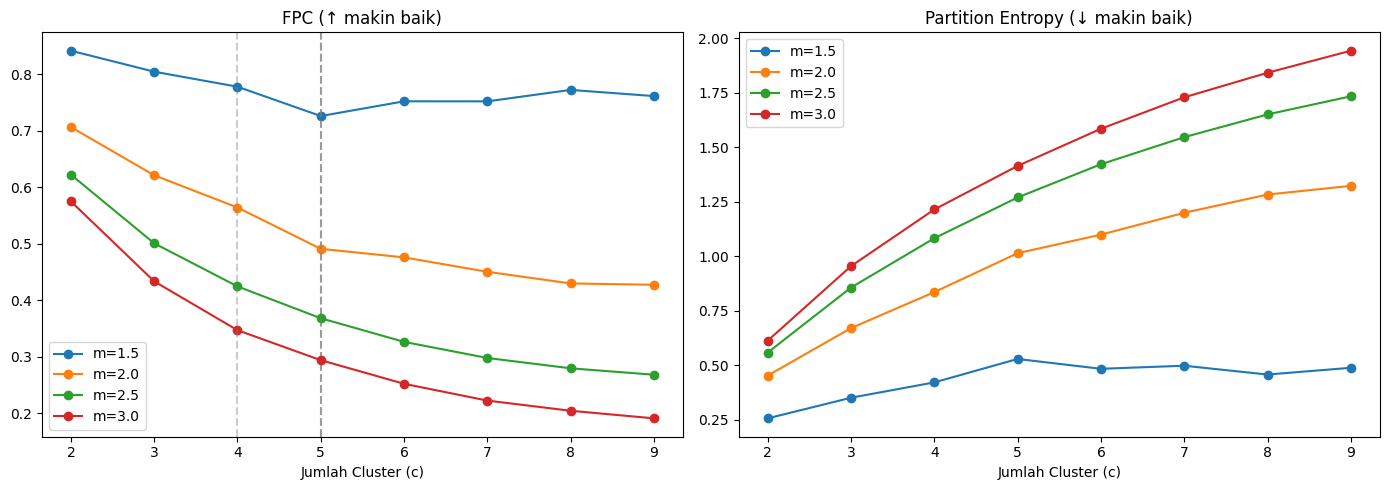

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

optimal_per_m = {}

for m_val in [1.5, 2.0, 2.5, 3.0]:
    subset = df_results[df_results['m'] == m_val].sort_values('c')
    c_vals   = subset['c'].tolist()
    fpc_vals = subset['fpc'].tolist()
    pe_vals  = subset['pe'].tolist()

    # Plot FPC & PE
    axes[0].plot(c_vals, fpc_vals, marker='o', label=f'm={m_val}')
    axes[1].plot(c_vals, pe_vals,  marker='o', label=f'm={m_val}')

    # KneeLocator per m
    kneedle = KneeLocator(
        c_vals, fpc_vals,
        curve='convex',
        direction='decreasing',
        S=0.5,
    )
    optimal_per_m[m_val] = kneedle.elbow

    # Tandai titik elbow di grafik
    if kneedle.elbow:
        elbow_fpc = subset[subset['c'] == kneedle.elbow]['fpc'].values[0]
        axes[0].axvline(
            x=kneedle.elbow,
            color='gray',
            linestyle='--',
            alpha=0.4
        )

axes[0].set_title('FPC (↑ makin baik)')
axes[1].set_title('Partition Entropy (↓ makin baik)')
for ax in axes:
    ax.set_xlabel('Jumlah Cluster (c)')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
for m_val, opt_c in optimal_per_m.items():
    best = df_results[
        (df_results['m'] == m_val) &
        (df_results['c'] == opt_c)
    ][['c', 'm', 'fpc', 'pe']].values
    print(f"m={m_val} → optimal c={opt_c} | {best}")

m=1.5 → optimal c=5 | [[5.         1.5        0.72636701 0.52955571]]
m=2.0 → optimal c=5 | [[5.         2.         0.49126851 1.01460868]]
m=2.5 → optimal c=5 | [[5.         2.5        0.36831855 1.270261  ]]
m=3.0 → optimal c=4 | [[4.         3.         0.34714979 1.21521124]]


In [ ]:
best = df_results[
    df_results.apply(
        lambda row: optimal_per_m.get(row['m']) == row['c'], axis=1
    )
].sort_values('fpc', ascending=False).iloc[0]

print(f"Kombinasi terbaik: c={best['c']}, m={best['m']}, FPC={best['fpc']:.4f}")

Kombinasi terbaik: c=5, m=1.5, FPC=0.7264


# **Profiling Each Cluster**

In [ ]:
u = best['u']
cluster_labels = np.argmax(u, axis=0)
lrfm_df["Cluster"] = cluster_labels

/tmp/ipykernel_3698/3138503973.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lrfm_df["Cluster"] = cluster_labels


In [ ]:
cluster_means = lrfm_df.groupby('Cluster')[['length', 'recency', 'frequency', 'monetary']].mean()
total_mean = lrfm_df[['length', 'recency', 'frequency', 'monetary']].mean()

comparison_df = cluster_means.copy()
comparison_df.loc['RATA-RATA TOTAL'] = total_mean

comparison_df

,length,recency,frequency,monetary
Cluster,,,,
0,0.011540,21.359428,1.012124,79.093154
1,0.025211,4.564050,1.005001,58.151081
2,1.254097,4.730375,1.256886,200.070997
3,0.017682,21.761081,1.010035,37.336003
4,0.242668,21.764243,1.137938,225.770537
RATA-RATA TOTAL,0.237754,15.923278,1.069443,112.820388


In [ ]:
cluster_std = lrfm_df.groupby("Cluster")[['length', 'recency', 'frequency', 'monetary']].std()
mean_std = cluster_std.mean()

In [ ]:
def assign_arrow(value, mean_value):
    return '↑' if value > mean_value else '↓'

profiling_df = pd.DataFrame(index=cluster_means.index)

In [ ]:
for col in ["length", "recency", "frequency", "monetary"]:
    profiling_df[col + '_arrow'] = cluster_std[col].apply(
        lambda x: assign_arrow(x, mean_std[col])
    )

profiling_df['Pola'] = (
    'L' + profiling_df['length_arrow'] +
    'R' + profiling_df['recency_arrow'] +
    'F' + profiling_df['frequency_arrow'] +
    'M' + profiling_df['monetary_arrow']
)

In [ ]:
segment_map = {
    'L↑R↓F↑M↑': 'High Value Loyal Customers',
    'L↑R↓F↑M↓': 'High Value New Customers',
    'L↑R↓F↓M↑': 'Platinum Customers',
    'L↑R↑F↑M↑': 'Potential Loyal Customers',
    'L↑R↑F↑M↓': 'Potential High Frequency Customers',
    'L↑R↑F↓M↑': 'Potential Consumption Customers',
    'L↓R↑F↑M↑': 'High Value Lost Customers',
    'L↓R↑F↑M↓': 'Frequency Lost Customers',
    'L↓R↑F↓M↑': 'Consumption Lost Customers',
    'L↓R↑F↓M↓': 'Uncertain Lost Customers',
    'L↓R↓F↑M↑': 'High Value New Customers',
    'L↓R↓F↑M↓': 'Frequency Promotions Customers',
    'L↓R↓F↓M↑': 'Consumption Promotions Customers',
    'L↓R↓F↓M↓': 'Uncertain New Customers',
    'L↑R↓F↓M↓': 'High Consumption Cost Customers',
    'L↑R↑F↓M↓': 'Low Consumption Cost Customers',
}

promo_map = {
    'High Value Loyal Customers': 'Sampling, cashback',
    'High Value New Customers': 'Cashback',
    'Platinum Customers': 'Cashback',
    'Potential Loyal Customers': 'Sampling, cashback',
    'Potential High Frequency Customers': 'Kupon, cashback',
    'Potential Consumption Customers': 'Buy One Get One Free',
    'High Value Lost Customers': 'Buy One Get One Free, Bonus Packs',
    'Frequency Lost Customers': 'Buy One Get One Free, Kupon',
    'Consumption Lost Customers': 'Bonus Packs, Kupon',
    'Uncertain Lost Customers': 'Kupon, Bonus Packs',
    'High Value New Customers': 'Buy One Get One Free, Cashback',
    'Frequency Promotions Customers': 'Price Off Deals, cashback',
    'Consumption Promotions Customers': 'Cashback',
    'Uncertain New Customers': 'Kupon, Buy One Get One Free',
    'High Consumption Cost Customers': 'Bonus Packs',
    'Low Consumption Cost Customers': 'Bonus Packs, Kupon',
}

profiling_df['Kelompok Pelanggan'] = profiling_df['Pola'].map(segment_map)
profiling_df['Rekomendasi Promosi'] = profiling_df['Kelompok Pelanggan'].map(promo_map)

In [ ]:
profiling_df[['Pola', 'Kelompok Pelanggan', 'Rekomendasi Promosi']]

,Pola,Kelompok Pelanggan,Rekomendasi Promosi
Cluster,,,
0,L↓R↑F↓M↓,Uncertain Lost Customers,"Kupon, Bonus Packs"
1,L↓R↓F↓M↓,Uncertain New Customers,"Kupon, Buy One Get One Free"
2,L↑R↓F↑M↑,High Value Loyal Customers,"Sampling, cashback"
3,L↓R↑F↓M↓,Uncertain Lost Customers,"Kupon, Bonus Packs"
4,L↓R↑F↓M↑,Consumption Lost Customers,"Bonus Packs, Kupon"


In [ ]:
# 1. Tentukan Direktori Penyimpanan
model_directory = "/content/drive/MyDrive/Research - Model Data Driven untuk Segmentasi Loyalitas Pelanggan dan Strategi Penjualan pada E-Commerce Menggunakan Metode Fuzzy C-Means dan Big Data Analytics/JD.com"
os.makedirs(model_directory, exist_ok=True)

# 2. Simpan Scaler
joblib.dump(scaler, os.path.join(model_directory, "scaler_lrfm.joblib"))

# 3. Simpan Pusat Klaster
joblib.dump(best['cntr'], os.path.join(model_directory, "fcm_centers.joblib"))

# 4. Simpan cluster_pola_map
# Mapping: cluster_id → pola (hasil profiling dari notebook)
cluster_pola_map = profiling_df['Pola'].to_dict()
# Contoh: {0: 'L↓R↑F↓M↓', 1: 'L↓R↓F↓M↓', 2: 'L↑R↓F↑M↑', ...}

# 5. Simpan semua metadata sekaligus
metadata = {
    "m": float(best['m']),
    "segment_map": segment_map,
    "promo_map": promo_map,
    "cluster_pola_map": {str(k): v for k, v in cluster_pola_map.items()},
}

with open(os.path.join(model_directory, "metadata_segmentasi.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

# Validasi sebelum simpan
print("✅ BERHASIL DISIMPAN!")
print(f"\nParameter model:")
print(f"  Jumlah cluster : {best['cntr'].shape[0]}")
print(f"  Nilai m        : {best['m']}")
print(f"  FPC            : {best['fpc']:.4f}")
print(f"\nCluster → Pola:")
for cluster_id, pola in cluster_pola_map.items():
    segmen = segment_map.get(pola, 'Unknown')
    print(f"  Cluster {cluster_id}: {pola} → {segmen}")
print(f"\nFile disimpan di:\n{model_directory}")

✅ BERHASIL DISIMPAN!

Parameter model:
  Jumlah cluster : 5
  Nilai m        : 1.5
  FPC            : 0.7264

Cluster → Pola:
  Cluster 0: L↓R↑F↓M↓ → Uncertain Lost Customers
  Cluster 1: L↓R↓F↓M↓ → Uncertain New Customers
  Cluster 2: L↑R↓F↑M↑ → High Value Loyal Customers
  Cluster 3: L↓R↑F↓M↓ → Uncertain Lost Customers
  Cluster 4: L↓R↑F↓M↑ → Consumption Lost Customers

File disimpan di:
/content/drive/MyDrive/Research - Model Data Driven untuk Segmentasi Loyalitas Pelanggan dan Strategi Penjualan pada E-Commerce Menggunakan Metode Fuzzy C-Means dan Big Data Analytics/JD.com


In [ ]:
print("done")

done
